# **DESARROLLO DEL PREPROCESAMIENTO DE LOS DATOS DE ENTRADA PARA LOS MODELOS DE MACHINE LEARNING DE CLASIFICACIÓN DE TEXTO DE LA BIBLIOTECA DE PYTHON "Scikit Learn", ENTRENAMIENTO DE MODELOS, EVALUACIÓN Y SERIALIZACIÓN**

**`EQUIPO 11 - HACKATHON ONE G9`**


# **CARGA DE DATOS DE ARCHIVOS `.csv`**

CARGA DE .CSVs CON LOS DATOS DE TRANSACCIONES.
-
Utilizamos el siguiente código:

```
import glob
import pandas as pd

# 1. Se obtiene la ruta de todos los archivos CSV
ruta_archivos = "/content/transacciones_csv/*.csv"
lista_archivos = glob.glob(ruta_archivos)

# 2. Se leen todos los archivos en una lista usando una lista de comprensión
lista_dataframes = [pd.read_csv(archivo) for archivo in lista_archivos]

# 3. Se concatenan todos los dataframes en uno solo
df_final = pd.concat(lista_dataframes, ignore_index=True)

```



In [ ]:
import glob
import pandas as pd

ruta_archivos = "/content/transacciones_csv/*.csv"
lista_archivos = glob.glob(ruta_archivos)

lista_dataframes = [pd.read_csv(archivo) for archivo in lista_archivos]

df_final = pd.concat(lista_dataframes, ignore_index=True)


In [ ]:
df_final.head()

,id_usuario,país,id_transaccion,fecha,descripcion,categoria,monto
0,PA_17,Panamá,PA_17_TR0001,2025-01-01,DGI (Dirección General de Ingresos),Servicios,2430.48
1,PA_17,Panamá,PA_17_TR0002,2025-01-01,Alimentos Genérico,Alimentacion,154.99
2,PA_17,Panamá,PA_17_TR0003,2025-01-01,Alimentos Genérico,Alimentacion,168.82
3,PA_17,Panamá,PA_17_TR0004,2025-01-01,Alimentos Genérico,Alimentacion,300.17
4,PA_17,Panamá,PA_17_TR0005,2025-01-01,Alimentos Genérico,Alimentacion,397.90


In [ ]:
df_final.shape

(3071653, 7)

# **CREACIÓN DE LAS LISTAS DE DATOS PARA EL APRENDIZAJE SUPERVISADO:**

* **DATOS DE ENTRADA (X) O DESCRIPCIONES (TEXTOS A CATEGORIZAR)**
* **DATOS DE SALIDA (y) O ETIQUETAS (CATEGORÍAS DE CLASIFICACIÓN DEFINIDAS)**

## DATOS DE ENTRADA (X)

In [ ]:
descripcion = df_final['descripcion'].to_list()

In [ ]:
type(descripcion)

list

In [ ]:
len(descripcion)

3071653

In [ ]:
print(descripcion[0:10])

['DGI (Dirección General de Ingresos)', 'Alimentos Genérico', 'Alimentos Genérico', 'Alimentos Genérico', 'Alimentos Genérico', 'Alimentos Genérico', 'Alimentos Genérico', 'Alimentos Genérico', 'Alimentos Genérico', 'Alimentos Genérico']


## DATOS DE SALIDA (y)

In [ ]:
categoria = df_final['categoria'].to_list()

In [ ]:
len(categoria)

3071653

In [ ]:
categoria[0:10]

['Servicios',
 'Alimentacion',
 'Alimentacion',
 'Alimentacion',
 'Alimentacion',
 'Alimentacion',
 'Alimentacion',
 'Alimentacion',
 'Alimentacion',
 'Alimentacion']

# **PREPROCESAMIENTO DE DATOS DE ENTRADA (X)**

<h2>En esta sección se desarrolla el preprocesamiento de los datos de entrada para una correcta utilización en los modelos de <strong>Scikit-Learn</strong>.</h2>

El preprocesamiento consta de dos partes principales:

- 1 - **Limpieza del texto**
  - Conversión a Minúsculas y puntuación
  - Palabras Vacías (Stop Words)
  - Lematización y Stemming
- 2 - **Vectorización**
  - Bolsa de Palabras (Bag of Words / BoW)
  - TF-IDF (Frecuencia de Término - Frecuencia Inversa de Documento)
  - Word Embeddings (Word2Vec / Transformers)

En este caso se utiliza `TfidfVectorizer` de la librería **Scikit-Learn** para la vectorización de los textos cortos que representan los nombres de comercios, empresas, instituciones educativas, gubernametales, plataformas, etc. Al utilizar este vectorizador y con palabras en idioma español se tiene en cuenta lo siguiente:

>
>  **`TfidfVectorizer`** nos probee diversas características:
> -
> * Convierte todo a **minúsculas** con el parámetro `lowercase=True` por defecto.
>
> * Elimina la **puntuación** básica ignorando comas, puntos, signos de interrogación y exclamación.
>
> * Elimina las tildes estableciendo el parámetro `strip_accents='unicode'`.
>
> * Elimina palabras vacías al recibir palabras listadas con el parámetro `stop_words=lista_de_palabras_vacias`
>

Nota: No aplicaremos la *lematización* en primera instancia y probaremos el modelo.

Se utiliza la siguiente lista de palabras en español incluyendo también al portugués para utilizarlas como lista de palabras vacías o stop words:

```
stop_words_latam_comercios = [
    # 1. Artículos y Preposiciones (Español)
    'el', 'la', 'los', 'las', 'un', 'una', 'unos', 'unas', 'lo', 'al', 'del',
    'a', 'ante', 'bajo', 'cabe', 'con', 'contra', 'de', 'desde', 'durante',
    'en', 'entre', 'hacia', 'hasta', 'mediante', 'para', 'por', 'segun',
    'sin', 'so', 'sobre', 'tras', 'via',

    # 2. Pronombres (Incluyendo "vos" latinoamericano)
    'yo', 'tu', 'vos', 'el', 'ella', 'ello', 'usted', 'nosotros', 'nosotras',
    'ustedes', 'ellos', 'ellas', 'me', 'te', 'se', 'nos', 'os', 'le', 'les',
    'lo', 'la', 'los', 'las', 'mi', 'mis', 'tu', 'tus', 'su', 'sus',
    'nuestro', 'nuestra', 'nuestros', 'nuestras',

    # 3. Conjunciones y Adverbios comunes
    'y', 'e', 'ni', 'que', 'o', 'u', 'pero', 'mas', 'sino', 'porque', 'pues',
    'aunque', 'si', 'como', 'donde', 'cuando', 'quien', 'cual', 'muy', 'mas',
    'menos', 'ya', 'aun', 'aqui', 'ahi', 'alli', 'hoy', 'ayer', 'mañana',
    'si', 'no', 'tambien', 'tampoco', 'asi',

    # 4. Verbos básicos (Ser, Estar, Haber, Tener - sin lematizar por si acaso)
    'ser', 'es', 'soy', 'eres', 'somos', 'son', 'fui', 'fue', 'estar', 'estoy',
    'esta', 'estamos', 'estan', 'haber', 'he', 'ha', 'hay', 'tener', 'tiene',
    'tienen', 'hacer', 'hace',

    # 5. Sufijos Empresariales / Legales (Latinoamérica)
    'sa', 's.a.', 's.a', 'srl', 's.r.l.', 's.r.l', 'ca', 'c.a.', 'c.a',
    'cia', 'cía', 'c.i.a', 'sas', 's.a.s.', 's.a.s', 'sac', 's.a.c.', 's.a.c',
    'eirl', 'e.i.r.l.', 'spa', 's.p.a.', 'inc', 'inc.', 'ltd', 'ltda', 'ltda.',
    'corp', 'corp.', 'corporacion', 'grupo', 'asociados', 'hermanos', 'hnos',
    'hnos.', 'hijos', 'sucursal',

    # 6. Anglicismos / Spanglish (Muy comunes en comercios latinos)
    'the', 'and', 'of', 'for', 'in', 'co', 'co.', 'company', 'bros', 'brothers',
    'store', 'shop', 'market', 'group', 'center',

    # 7. Inclusiones para Brasil (Portugués básico)
    'o', 'a', 'os', 'as', 'um', 'uma', 'uns', 'umas', 'do', 'da', 'dos', 'das',
    'no', 'na', 'nos', 'nas', 'em', 'com', 'sem', 'por', 'para', 'e'
]
```

Teniendo en cuenta todo esto el vectorizador se instancia de la siguiente forma:

```
from sklearn.feature_extraction.text import TfidfVectorizer

# Instanciamos el vectorizador con la lista creada
vectorizador = TfidfVectorizer(
    stop_words=stop_words_latam_comercios, # Lista de palabras vacías
    lowercase=True,                        # Pasa todo a minúsculas
    strip_accents='unicode'                # Elimina tildes (ej: "compañía" -> "compania")
)
```

Luego aplicamos el **vectorizador** a nuestros textos:

```
X = vectorizador.fit_transform(descripcion)
```


## **1 - CREO LA LISTA DE PALABRAS VACÍAS O STOP WORDS**

In [ ]:
stop_words_latam_comercios = [
    # 1. Artículos y Preposiciones (Español)
    'el', 'la', 'los', 'las', 'un', 'una', 'unos', 'unas', 'lo', 'al', 'del',
    'a', 'ante', 'bajo', 'cabe', 'con', 'contra', 'de', 'desde', 'durante',
    'en', 'entre', 'hacia', 'hasta', 'mediante', 'para', 'por', 'segun',
    'sin', 'so', 'sobre', 'tras', 'via',

    # 2. Pronombres (Incluyendo "vos" latinoamericano)
    'yo', 'tu', 'vos', 'el', 'ella', 'ello', 'usted', 'nosotros', 'nosotras',
    'ustedes', 'ellos', 'ellas', 'me', 'te', 'se', 'nos', 'os', 'le', 'les',
    'lo', 'la', 'los', 'las', 'mi', 'mis', 'tu', 'tus', 'su', 'sus',
    'nuestro', 'nuestra', 'nuestros', 'nuestras',

    # 3. Conjunciones y Adverbios comunes
    'y', 'e', 'ni', 'que', 'o', 'u', 'pero', 'mas', 'sino', 'porque', 'pues',
    'aunque', 'si', 'como', 'donde', 'cuando', 'quien', 'cual', 'muy', 'mas',
    'menos', 'ya', 'aun', 'aqui', 'ahi', 'alli', 'hoy', 'ayer', 'mañana',
    'si', 'no', 'tambien', 'tampoco', 'asi',

    # 4. Verbos básicos (Ser, Estar, Haber, Tener - sin lematizar por si acaso)
    'ser', 'es', 'soy', 'eres', 'somos', 'son', 'fui', 'fue', 'estar', 'estoy',
    'esta', 'estamos', 'estan', 'haber', 'he', 'ha', 'hay', 'tener', 'tiene',
    'tienen', 'hacer', 'hace',

    # 5. Sufijos Empresariales / Legales (Latinoamérica)
    'sa', 's.a.', 's.a', 'srl', 's.r.l.', 's.r.l', 'ca', 'c.a.', 'c.a',
    'cia', 'cía', 'c.i.a', 'sas', 's.a.s.', 's.a.s', 'sac', 's.a.c.', 's.a.c',
    'eirl', 'e.i.r.l.', 'spa', 's.p.a.', 'inc', 'inc.', 'ltd', 'ltda', 'ltda.',
    'corp', 'corp.', 'corporacion', 'grupo', 'asociados', 'hermanos', 'hnos',
    'hnos.', 'hijos', 'sucursal',

    # 6. Anglicismos / Spanglish (Muy comunes en comercios latinos)
    'the', 'and', 'of', 'for', 'in', 'co', 'co.', 'company', 'bros', 'brothers',
    'store', 'shop', 'market', 'group', 'center',

    # 7. Inclusiones para Brasil (Portugués básico)
    'o', 'a', 'os', 'as', 'um', 'uma', 'uns', 'umas', 'do', 'da', 'dos', 'das',
    'no', 'na', 'nos', 'nas', 'em', 'com', 'sem', 'por', 'para', 'e'
]

## **2 - CREO EL VECTORIZADOR CON `TfidfVectorizer`**

TF-IDF Vectorizer

```
from sklearn.feature_extraction.text import TfidfVectorizer

# Instanciamos el vectorizador con la lista creada
vectorizador = TfidfVectorizer(
    stop_words=stop_words_latam_comercios, # Lista de palabras vacías
    lowercase=True,                        # Pasa todo a minúsculas
    strip_accents='unicode'                # Elimina tildes (ej: "compañía" -> "compania")
)
```



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizador = TfidfVectorizer(
    stop_words=stop_words_latam_comercios,
    lowercase=True,
    strip_accents='unicode'
)

## **3 - VECTORIZACIÓN DEL TEXTO DE ENTRADA** **`descripcion -> X`**

In [ ]:
X = vectorizador.fit_transform(descripcion)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['manana'] not in stop_words.
  warnings.warn(


# **CODIFICACIÓN DE LAS CATEGORÍAS O DATOS DE SALIDA (y)**

Para la codificación de la variable objetivo, target, o dato de salida del modelo (y) utilizaremos `LabelEncoder` provisto en la biblioteca **Scikit Learn**.

Este codificador debe ser utilizado por la naturaleza del tipo de clasificación que vamos a realizar y en forma exclusiva para la variable objetivo en Scikit Learn.

```
from sklearn.preprocessing import LabelEncoder

# Instanciación del codificador
label_encoder = LabelEncoder()

# Codificación de Etiquetas
y = label_encoder.fit_transform(categoria)
```



## **1 - CREO EL CODIFICADOR**

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()

## **2 - CODIFICO LAS ETIQUETAS O CATEGORÍAS** **`categoria -> y`**

In [ ]:
y = label_encoder.fit_transform(categoria)

In [ ]:
print(label_encoder.classes_)

['Alimentacion' 'Educacion' 'Electrodomesticos' 'Inversion' 'Ocio' 'Salud'
 'Servicios' 'Transporte' 'Vestimenta' 'Vivienda']


# **DIVISIÓN DEL CONJUNTO DE DATOS O SPLIT**

División del conjunto de datos para entrenamiento y pueba del modelo:

>Entrenaminto:
>  - **`X_train`** e **`y_train`**
>
>Prueba:
>  - **`X_test`** e **`y_test`**

Para ello utilizaremos la misma biblioteca **Scikit Learn** que nos probee de un método para realizar este paso:



```
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=11)
```

En este caso utilizamos el 20% de los datos para asignarlos al conjunto de prueba, por lo que entrenamos el modelo con el 80% de los datos, mediante el parámetro `test_size=0.20` y aplicamos en este caso para futuras comparaciones una semilla de estado aleatorio de la selección de los datos con el parámetro `random_state=11`.


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=11)

# **ENTRENAMIENTO DE LOS MODELOS DE CLASIFICACIÓN**

Entrenamos en primer lugar los modelos de clasificación **"Naive Bayes"** de la biblioteca **Scikit Learn** y luego entrenamos el modelo de **"Regresión Logística"**.

En el caso de los algoritmos de clasificación **Naive Bayes** tenemos dos opciones para nuestro caso en el que utilizamos la vectorizacion TF-IDF para los datos de entrada: **MultinomialNB** y **ComplementNB**.

En cuanto a los modelos sabemos que:

* **MultinomialNB** es una opción estándar en la industria y funciona bien con TF-IDF.
* **CategoricalNB** es una opción mejorada que corrije el problema de categorías muy desiguales o desbalanceadas.



```
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression

# Instancio los modelos
modelo_nbm = MultinomialNB()
modelo_nbc = ComplementNB()
modelo_rlog = LogisticRegression(max_iter=1000)
```



## **1 - ENTRENO LOS MODELOS NAIVE BAYES**

In [ ]:
from sklearn.naive_bayes import MultinomialNB, ComplementNB

In [ ]:
modelo_nbm = MultinomialNB()

In [ ]:
modelo_nbc = ComplementNB()

In [ ]:
modelo_nbm.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](10,)","[330363., 97029., 52177.,...,957869., 74553.,195649.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](10,)","[-2.01,-3.23,-3.85,...,-0.94,-3.5 ,-2.53]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](10, 2854)","[[ 195.62, 0. , 0. ,..., 215.42, 0. , 0. ], [ 0. , 0. , 408.37,..., 0. , 0. , 0. ], [ 0. , 0. , 0. ,..., 0. , 0. , 0. ], ..., [ 0. ,1891. , 0. ,..., 0. , 0. , 0. ], [ 0. , 0. , 0. ,..., 0. , 0. , 0. ], [ 0. , 0. , 0. ,..., 0. , 266. , 0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](10, 2854)","[[ -7.76,-13.04,-13.04,..., -7.66,-13.04,-13.04], [-11.91,-11.91, -5.9 ,...,-11.91,-11.91,-11.91], [-11.12,-11.12,-11.12,...,-11.12,-11.12,-11.12], ..., [-14.03, -6.48,-14.03,...,-14.03,-14.03,-14.03], [-11.42,-11.42,-11.42,...,-11.42,-11.42,-11.42], [-12.56,-12.56,-12.56,...,-12.56, -6.97,-12.56]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2854


In [ ]:
modelo_nbc.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueOnly used in edge case with a single class in the training set.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. Not used.",None
,"norm norm: bool, default=FalseWhether or not a second normalization of the weights is performed. Thedefault behavior mirrors the implementations found in Mahout and Weka,which do not follow the full algorithm described in Table 9 of thepaper.",False
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](10,)","[330363., 97029., 52177.,...,957869., 74553.,195649.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class. Only used in edgecase with a single class in the training set.","ndarray[float64](10,)","[-2.01,-3.23,-3.85,...,-0.94,-3.5 ,-2.53]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
"feature_all_ feature_all_: ndarray of shape (n_features,)Number of samples encountered for each feature during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2854,)","[ 638.18,1891. , 805.65,..., 397.93, 266. , 293.96]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature) during fitting.This value is weighted by the sample weight when provided.","ndarray[float64](10, 2854)","[[ 195.62, 0. , 0. ,..., 215.42, 0. , 0. ], [ 0. , 0. , 408.37,..., 0. , 0. , 0. ], [ 0. , 0. , 0. ,..., 0. , 0. , 0. ], ..., [ 0. ,1891. , 0. ,..., 0. , 0. , 0. ], [ 0. , 0. , 0. ,..., 0. , 0. , 0. ], [ 0. , 0. , 0. ,..., 0. , 266. , 0. ]]"


## **2 - ENTRENO EL MODELO DE REGRESIÓN LOGÍSTICA**

Entrenamos en segundo lugar el modelo de clasificación **"Regresión Logística"** de la biblioteca **Scikit Learn**. En este caso colocaremos el parámetro `max_iter=1000` en la primera prueba del modelo.

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
modelo_rlog = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=11)

In [ ]:
modelo_rlog.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",11
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

## **3 - REALIZO LAS PREDICCIONES CON LOS CONJUNTOS DE PRUEBA**

In [ ]:
y_prediccion_nbm = modelo_nbm.predict(X_test)

In [ ]:
y_prediccion_nbc = modelo_nbc.predict(X_test)

In [ ]:
y_prediccion_rlog = modelo_rlog.predict(X_test)

## **4 - EVALÚO EL DESEMPEÑO DE LOS MODELOS**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
print(classification_report(y_test, y_prediccion_nbm))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     82654
           1       1.00      0.98      0.99     24300
           2       0.83      0.86      0.85     13122
           3       1.00      1.00      1.00     28865
           4       1.00      0.98      0.99     42241
           5       0.99      0.99      0.99     54843
           6       0.99      0.99      0.99     61242
           7       0.99      1.00      0.99    239258
           8       0.93      0.94      0.94     18802
           9       0.99      0.95      0.97     49004

    accuracy                           0.99    614331
   macro avg       0.97      0.97      0.97    614331
weighted avg       0.99      0.99      0.99    614331



In [ ]:
print(classification_report(y_test, y_prediccion_nbc))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     82654
           1       0.99      0.98      0.99     24300
           2       0.81      0.84      0.82     13122
           3       1.00      1.00      1.00     28865
           4       1.00      0.97      0.99     42241
           5       0.99      0.99      0.99     54843
           6       0.99      0.99      0.99     61242
           7       0.99      1.00      1.00    239258
           8       0.93      0.92      0.93     18802
           9       0.98      0.95      0.96     49004

    accuracy                           0.98    614331
   macro avg       0.97      0.96      0.97    614331
weighted avg       0.98      0.98      0.98    614331



In [ ]:
print(classification_report(y_test, y_prediccion_rlog))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     82654
           1       0.96      1.00      0.98     24300
           2       0.81      0.99      0.89     13122
           3       1.00      1.00      1.00     28865
           4       1.00      0.99      1.00     42241
           5       1.00      1.00      1.00     54843
           6       0.98      1.00      0.99     61242
           7       1.00      0.99      1.00    239258
           8       0.97      0.95      0.96     18802
           9       1.00      0.96      0.98     49004

    accuracy                           0.99    614331
   macro avg       0.97      0.99      0.98    614331
weighted avg       0.99      0.99      0.99    614331



## **5 - MATRICES DE CONFUSIÓN**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

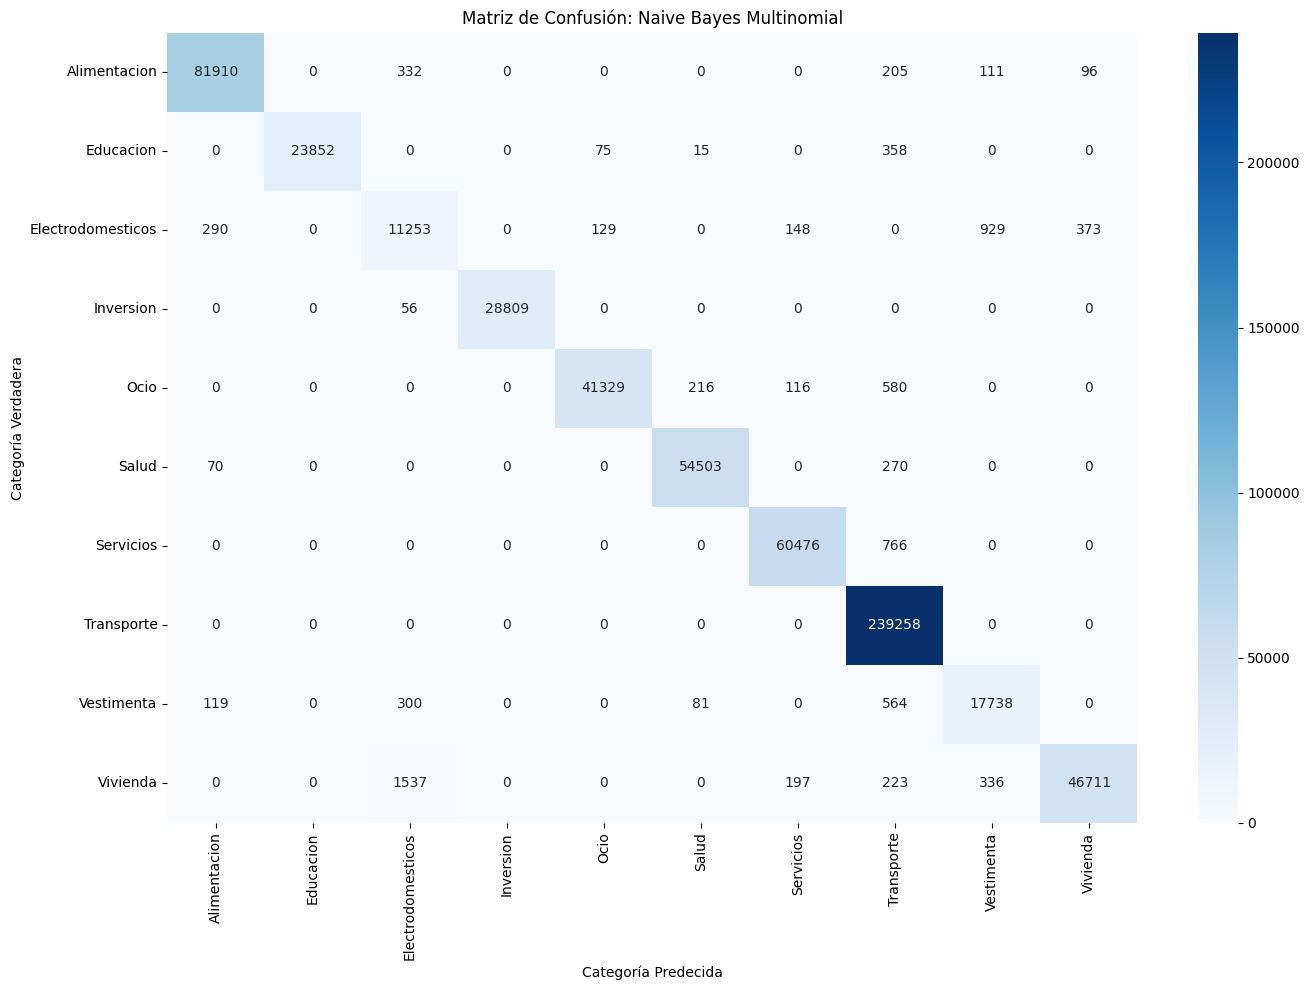

In [ ]:
# Visualizo la Matriz de Confusion para Naive Bayes Multinomial
name_nbm = 'Naive Bayes Multinomial'

fig, ax = plt.subplots(figsize=(14, 10))

cm = confusion_matrix(y_test, y_prediccion_nbm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Alimentacion', 'Educacion' ,'Electrodomesticos' ,'Inversion' ,'Ocio' ,'Salud', 'Servicios' ,'Transporte' ,'Vestimenta' ,'Vivienda'],
            yticklabels=['Alimentacion', 'Educacion' ,'Electrodomesticos' ,'Inversion' ,'Ocio' ,'Salud', 'Servicios' ,'Transporte' ,'Vestimenta' ,'Vivienda'])
ax.set_title(f'Matriz de Confusión: {name_nbm}')
ax.set_xlabel('Categoría Predecida')
ax.set_ylabel('Categoría Verdadera')

plt.tight_layout()
plt.show()

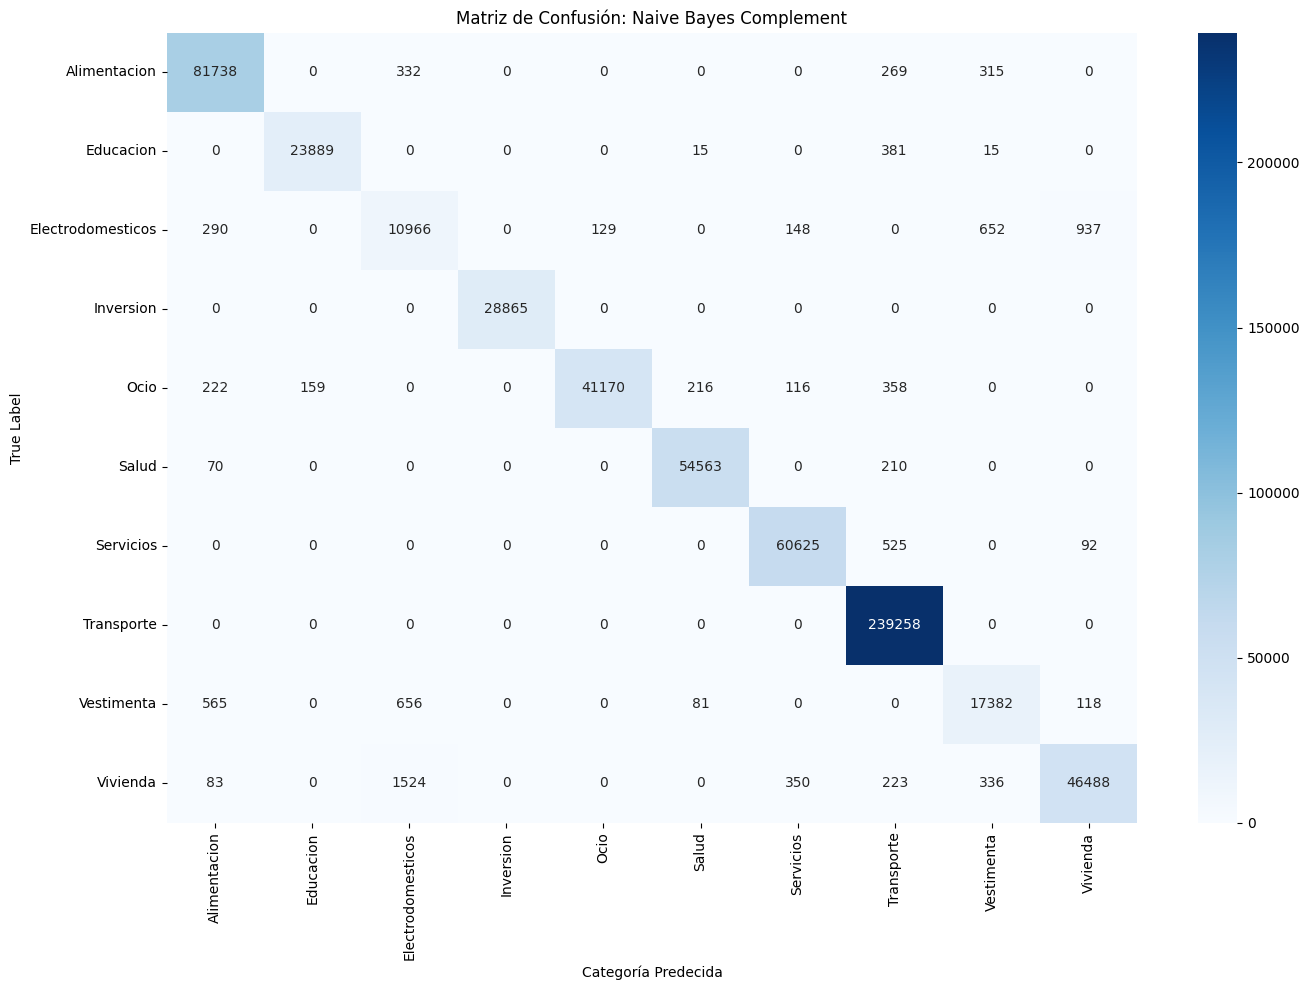

In [ ]:
# Visualizo la Matriz de Confusion para Naive Bayes Complement
name_nbc = 'Naive Bayes Complement'

fig, ax = plt.subplots(figsize=(14, 10))

cm = confusion_matrix(y_test, y_prediccion_nbc)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Alimentacion', 'Educacion' ,'Electrodomesticos' ,'Inversion' ,'Ocio' ,'Salud', 'Servicios' ,'Transporte' ,'Vestimenta' ,'Vivienda'],
            yticklabels=['Alimentacion', 'Educacion' ,'Electrodomesticos' ,'Inversion' ,'Ocio' ,'Salud', 'Servicios' ,'Transporte' ,'Vestimenta' ,'Vivienda'])
ax.set_title(f'Matriz de Confusión: {name_nbc}')
ax.set_xlabel('Categoría Predecida')
ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

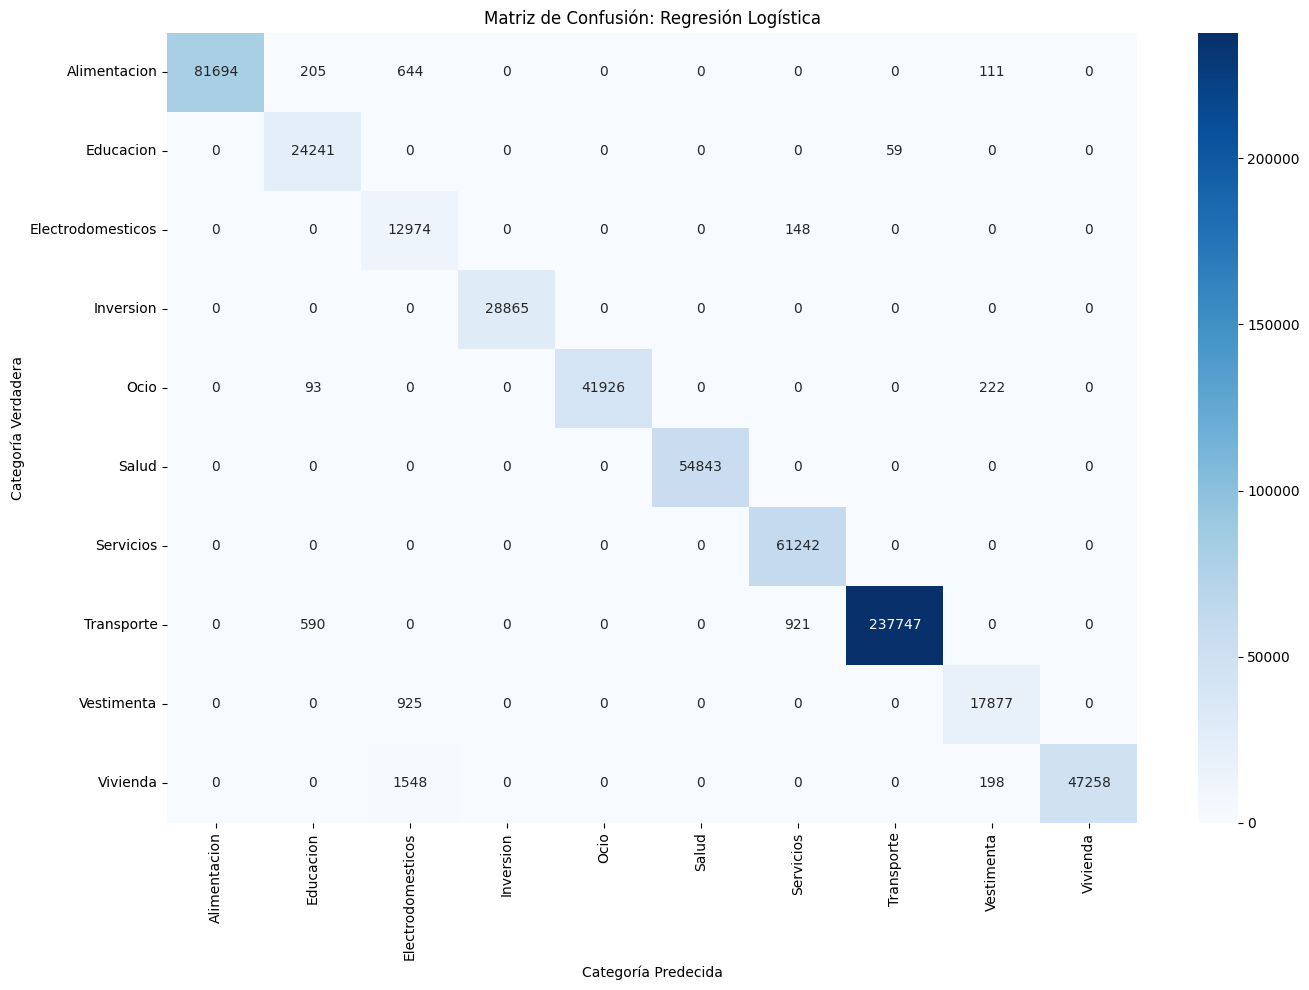

In [ ]:
# Visualizo la Matriz de Confusion para Regresión Logística
name_rlog = 'Regresión Logística'

fig, ax = plt.subplots(figsize=(14, 10))

cm = confusion_matrix(y_test, y_prediccion_rlog)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Alimentacion', 'Educacion' ,'Electrodomesticos' ,'Inversion' ,'Ocio' ,'Salud', 'Servicios' ,'Transporte' ,'Vestimenta' ,'Vivienda'],
            yticklabels=['Alimentacion', 'Educacion' ,'Electrodomesticos' ,'Inversion' ,'Ocio' ,'Salud', 'Servicios' ,'Transporte' ,'Vestimenta' ,'Vivienda'])
ax.set_title(f'Matriz de Confusión: {name_rlog}')
ax.set_xlabel('Categoría Predecida')
ax.set_ylabel('Categoría Verdadera')

plt.tight_layout()
plt.show()

# **SERIALIZACIÓN DE LOS MODELOS**

## **1 - INSTALACIÓN DE BIBLIOTECAS PARA TRABAJAR CON ONNX.**

Consideraciones:

* `onnxruntime` no es necesaria para la serialización. Lo utilizamos para probar la ejecución del modelo serializado.
* Realizamos `--upgrade` de scikit-learn y skl2onnx para evitar errores con **ComplementNB**.

In [ ]:
!pip install skl2onnx onnxruntime

In [ ]:
!pip install --upgrade scikit-learn skl2onnx

## **2 - SERIALIZACIÓN DE LOS MODELOS CON ONNX.**

**Utilizamos el siguiente código para serializar utilizando ONNX.**



```
from sklearn.pipeline import Pipeline
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import StringTensorType

# 1. Definimos la forma de los datos de entrada (matriz de textos)
# Esto no cambia, Java sigue necesitando saber qué va a recibir
tipo_entrada = [('texto_entrada', StringTensorType([None, 1]))]

# 2. Agrupamos tus modelos YA ENTRENADOS en un diccionario para iterar
# Nota: Ensamblamos el Pipeline al vuelo juntando tu vectorizador y tu modelo
modelos_exportar = {
    "MultinomialNB": Pipeline([
        ('vectorizador', vectorizador), # Reemplaza por el nombre de tu variable TfidfVectorizer
        ('clasificador', modelo_nbm)
    ]),
    "ComplementNB": Pipeline([
        ('vectorizador', vectorizador),
        ('clasificador', modelo_nbc)
    ]),
    "LogisticRegression": Pipeline([
        ('vectorizador', vectorizador),
        ('clasificador', modelo_rlog)
    ])
}

# 3. Bucle para exportar directamente
for nombre, pipeline_entrenado in modelos_exportar.items():
    try:
        # Convertimos usando el pipeline ya ajustado (no usamos .fit() aquí)
        modelo_onnx = convert_sklearn(
            pipeline_entrenado,
            initial_types=tipo_entrada,
            target_opset=12
        )
        
        # Guardamos el archivo
        nombre_archivo = f"modelo_{nombre.lower()}.onnx"
        with open(nombre_archivo, "wb") as f:
            f.write(modelo_onnx.SerializeToString())
            
        print(f"✅ {nombre} exportado con éxito como: {nombre_archivo}")
        
    except Exception as e:
        print(f"❌ Error al exportar {nombre}: {e}")
```



In [ ]:
from sklearn.pipeline import Pipeline
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import StringTensorType

In [ ]:
tipo_entrada = [('texto_entrada', StringTensorType([None, 1]))]

In [ ]:
modelos_exportar = {
    "MultinomialNB": Pipeline([
        ('vectorizador', vectorizador),
        ('clasificador', modelo_nbm)
    ]),
    "ComplementNB": Pipeline([
        ('vectorizador', vectorizador),
        ('clasificador', modelo_nbc)
    ]),
    "LogisticRegression": Pipeline([
        ('vectorizador', vectorizador),
        ('clasificador', modelo_rlog)
    ])
}

In [ ]:
for nombre, pipeline_entrenado in modelos_exportar.items():
    try:
        # Convertimos usando el pipeline ya ajustado
        modelo_onnx = convert_sklearn(
            pipeline_entrenado,
            initial_types=tipo_entrada,
            target_opset=12
        )

        # Guardamos el archivo
        nombre_archivo = f"modelo_{nombre.lower()}.onnx"
        with open(nombre_archivo, "wb") as f:
            f.write(modelo_onnx.SerializeToString())

        print(f"✅ {nombre} exportado con éxito como: {nombre_archivo}")

    except Exception as e:
        print(f"❌ Error al exportar {nombre}: {e}")

❌ Error al exportar MultinomialNB: CountVectorizer cannot be converted, only strip_accents=None is supported. You may raise an issue at https://github.com/onnx/sklearn-onnx/issues.
❌ Error al exportar ComplementNB: CountVectorizer cannot be converted, only strip_accents=None is supported. You may raise an issue at https://github.com/onnx/sklearn-onnx/issues.
❌ Error al exportar LogisticRegression: CountVectorizer cannot be converted, only strip_accents=None is supported. You may raise an issue at https://github.com/onnx/sklearn-onnx/issues.


Para manejar `strip_accents='unicode'` engañamos a ONNX.



```
# ... [código anterior] ...

# 1. EL TRUCO: Forzar el parámetro a None en el vectorizador ya entrenado.
# Como el vocabulario ya está aprendido (sin acentos), esto no rompe el modelo,
# solo engaña a la validación de skl2onnx.
vectorizador.strip_accents = None

# 2. Bucle para exportar directamente (igual que antes)
for nombre, pipeline_entrenado in modelos_exportar.items():
    try:
        modelo_onnx = convert_sklearn(
            pipeline_entrenado,
            initial_types=tipo_entrada,
            target_opset=12
        )
        
        nombre_archivo = f"modelo_{nombre.lower()}.onnx"
        with open(nombre_archivo, "wb") as f:
            f.write(modelo_onnx.SerializeToString())
            
        print(f"✅ {nombre} exportado con éxito")
        
    except Exception as e:
        print(f"❌ Error al exportar {nombre}: {e}")
```



In [ ]:
vectorizador.strip_accents = None

In [ ]:
for nombre, pipeline_entrenado in modelos_exportar.items():
    try:
        modelo_onnx = convert_sklearn(
            pipeline_entrenado,
            initial_types=tipo_entrada,
            target_opset=12
        )

        nombre_archivo = f"modelo_{nombre.lower()}.onnx"
        with open(nombre_archivo, "wb") as f:
            f.write(modelo_onnx.SerializeToString())

        print(f"✅ {nombre} exportado con éxito")

    except Exception as e:
        print(f"❌ Error al exportar {nombre}: {e}")

✅ MultinomialNB exportado con éxito
✅ ComplementNB exportado con éxito
✅ LogisticRegression exportado con éxito


## **3 - MATERIAL PARA BACKEND**

**Diccionario para el equipo de backend**

El modelo devuelve números (usamos `LabelEncoder`) por lo que deverá ser decodificado.



```
# Generamos el diccionario para dárselo al equipo de backend
diccionario_categorias = {indice: str(categoria) for indice, categoria in enumerate(le.classes_)}
print("Diccionario para el equipo de backend:")
print(diccionario_categorias)
```



In [ ]:
diccionario_categorias = {indice: str(categoria) for indice, categoria in enumerate(label_encoder.classes_)}
print("Diccionario para el equipo de backend:")
print(diccionario_categorias)

Diccionario para el equipo de backend:
{0: 'Alimentacion', 1: 'Educacion', 2: 'Electrodomesticos', 3: 'Inversion', 4: 'Ocio', 5: 'Salud', 6: 'Servicios', 7: 'Transporte', 8: 'Vestimenta', 9: 'Vivienda'}


**Instrucciones:**

* Debe procesarse el texto antes de inyectarlo al modelo.

* Se puede utilizar el siguiente código JAVA:



```
import java.text.Normalizer;

public class PreprocesamientoTexto {
    
    // Este método emula exactamente el comportamiento de strip_accents='unicode'
    public static String quitarAcentos(String textoOriginal) {
        if (textoOriginal == null) return null;
        
        // 1. Normaliza el texto separando los caracteres de sus tildes/acentos
        String textoNormalizado = Normalizer.normalize(textoOriginal, Normalizer.Form.NFD);
        
        // 2. Elimina los símbolos de acentuación usando una expresión regular
        return textoNormalizado.replaceAll("\\p{M}", "");
    }
}
```

En producción:

* Spring Boot recibe un texto con acentos: "Compañía de ejemplo SRL"

* Spring Boot pasa el texto por la función quitarAcentos -> "Compañia de ejemplo SRL"

* Spring Boot envía ese texto limpio al archivo .onnx (que ahora funcionará perfectamente porque coincide con el vocabulario que aprendió en Python).



**Diccionario para Backend en JSON**



```
import json

# 1. Creamos el diccionario limpio (con str)
diccionario_etiquetas = {indice: str(etiqueta) for indice, etiqueta in enumerate(le.classes_)}

# 2. Lo convertimos a formato JSON
diccionario_json = json.dumps(diccionario_etiquetas, indent=4)

print("Entregar este JSON al equipo de Java:")
print(diccionario_json)
```



In [ ]:
import json

In [ ]:
diccionario_json = json.dumps(diccionario_categorias, indent=4)

print("Entregar este JSON al equipo de Java:")
print(diccionario_json)

Entregar este JSON al equipo de Java:
{
    "0": "Alimentacion",
    "1": "Educacion",
    "2": "Electrodomesticos",
    "3": "Inversion",
    "4": "Ocio",
    "5": "Salud",
    "6": "Servicios",
    "7": "Transporte",
    "8": "Vestimenta",
    "9": "Vivienda"
}


GUARDO EL DICCIONARIO EN UN ARCHIVO `.json`

In [ ]:
with open('diccionario_categorias.json', 'w', encoding='utf-8') as f:
    f.write(diccionario_json)

print("Diccionario guardado en 'diccionario_categorias.json'")

Diccionario guardado en 'diccionario_categorias.json'
